In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [7]:
df=pd.read_csv('supermarket_sales - Sheet1.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [11]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [13]:
df['Date']=pd.to_datetime(df['Date'])
df['Time']=pd.to_datetime(df['Time'])
df['Hour']=df['Time'].dt.hour


/tmp/ipykernel_19187/1241242852.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time']=pd.to_datetime(df['Time'])


In [15]:
print(df.groupby('Branch').agg(
    Total_Sales=('Total','sum'),
    Order_Count=('Total','size')
))

        Total_Sales  Order_Count
Branch                          
A       106200.3705          340
B       106197.6720          332
C       110568.7065          328


In [17]:
print(df.groupby('Product line').agg(
    Total_Sales=('Total','sum'),
    Order_Count=('Total','size')
))

                        Total_Sales  Order_Count
Product line                                    
Electronic accessories   54337.5315          170
Fashion accessories      54305.8950          178
Food and beverages       56144.8440          174
Health and beauty        49193.7390          152
Home and lifestyle       53861.9130          160
Sports and travel        55122.8265          166


In [18]:
print(
    df.groupby('Customer type').agg(
        Total_Sales=('Total','sum'),
        Order_Count=('Total','size')
    )
)

               Total_Sales  Order_Count
Customer type                          
Member          164223.444          501
Normal          158743.305          499


In [19]:
print(df.groupby('Gender').agg(
    Total_Sales=('Total', 'sum'),
    Order_Count=('Total', 'size')
))

        Total_Sales  Order_Count
Gender                          
Female   167882.925          501
Male     155083.824          499


In [20]:
hourly_sales = df.groupby('Hour')['Total'].sum()
print(hourly_sales.sort_values(ascending=False).head())

Hour
19    39699.5130
13    34723.2270
10    31421.4810
15    31179.5085
14    30828.3990
Name: Total, dtype: float64


In [21]:
sales = df.groupby('Product line')['Total'].sum()

print("\n--- TOP Products ---")
print(sales.sort_values(ascending=False).head())

print("\n--- BOTTOM Products ---")
print(sales.sort_values().head())


--- TOP Products ---
Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Name: Total, dtype: float64

--- BOTTOM Products ---
Product line
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Fashion accessories       54305.8950
Electronic accessories    54337.5315
Sports and travel         55122.8265
Name: Total, dtype: float64


In [22]:
print(df.groupby('Product line')['gross margin percentage'].mean())

Product line
Electronic accessories    4.761905
Fashion accessories       4.761905
Food and beverages        4.761905
Health and beauty         4.761905
Home and lifestyle        4.761905
Sports and travel         4.761905
Name: gross margin percentage, dtype: float64


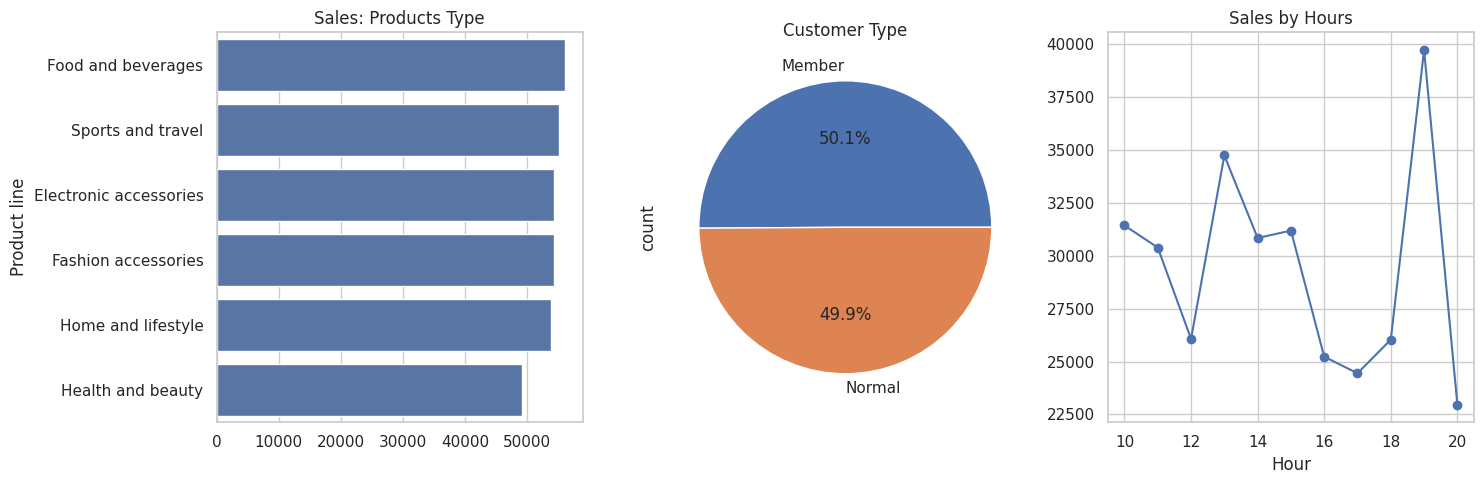

In [39]:
# Visualizations
plt.figure(figsize=(15,5))

# 1. Bar Chart
plt.subplot(1,3,1)
sales_sorted = sales.sort_values(ascending=False)
sns.barplot(x=sales_sorted.values, y=sales_sorted.index)
plt.title("Sales: Products Type")

# 2. Pie Chart
plt.subplot(1,3,2)
df['Customer type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Customer Type")

# 3. Line Chart
plt.subplot(1,3,3)
plt.plot(hourly_sales.index, hourly_sales.values, marker='o')
plt.title("Sales by Hours")
plt.xlabel("Hour")

plt.tight_layout()
plt.show()

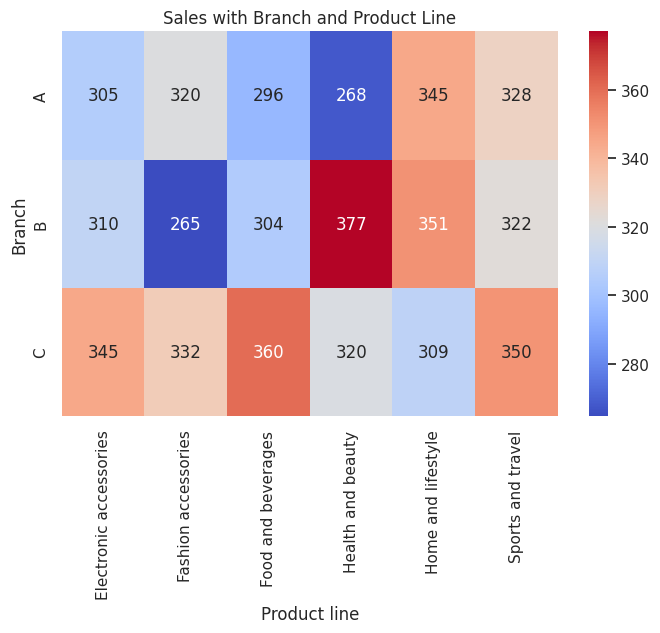

In [43]:
# Heatmap
plt.figure(figsize=(8,5))

pivot = df.pivot_table(values='Total', index='Branch', columns='Product line')
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("Sales with Branch and Product Line")
plt.show()